# Figure 7 - Biological synaptic update rules

In [1]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gs
import h5py

import EIANN.utils as ut
import EIANN.plot as pt
from EIANN.generate_figures import *

pt.update_plot_defaults()
root_dir = ut.get_project_root()

%load_ext autoreload
%autoreload 2

/Users/ag1880/github-repos/Milstein-Lab/EIANN/EIANN/utils/representation_analysis.py:8: TqdmExperimentalWarning: Using `tqdm.autonotebook.tqdm` in notebook mode. Use `tqdm.tqdm` instead to force console mode (e.g. in jupyter console)
  from tqdm.autonotebook import tqdm


In [2]:
figure_name = "Fig5_BTSP_BCM_HebbWN"
model_list = ["bpLike_WT_hebbdend", "BTSP_WT_hebbdend", "Supervised_BCM_WT_hebbdend","SupHebbTempCont_WT_hebbdend"]
model_dict_all = load_model_dict()
generate_hdf5_all_seeds(model_list, model_dict_all, recompute=None, variables_to_save = ['accuracy', 'dendritic_state', 'angle_vs_bp'])

Generating plots for LDS
Generating plots for BTSP
Generating plots for BCM
Generating plots for TCH


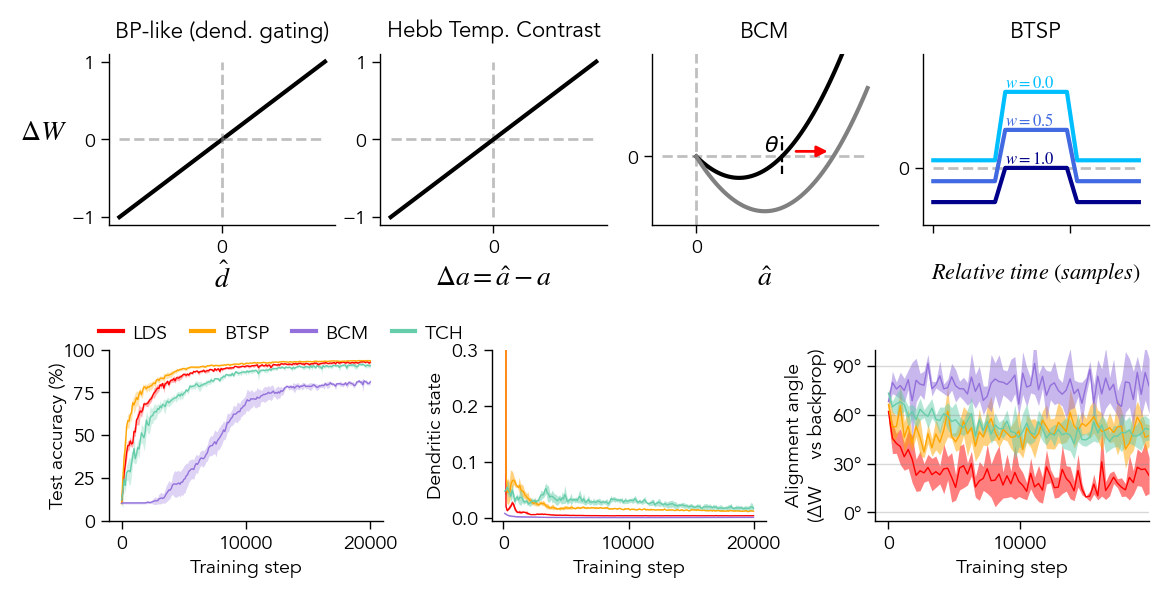

In [3]:
fig = plt.figure(figsize=(6.5, 9))
axes = gs.GridSpec(nrows=2, ncols=3, figure=fig,                       
                    left=0.1,right=0.9,
                    top=0.9, bottom = 0.6,
                    wspace=0.4, hspace=0.6,
                    height_ratios=[1, 0.7])
ax_accuracy = fig.add_subplot(axes[1,0])
ax_dendstate = fig.add_subplot(axes[1,1])
ax_angle_vs_BP = fig.add_subplot(axes[1,2])

axes = gs.GridSpecFromSubplotSpec(nrows=1, ncols=4, subplot_spec=axes[0,0:3], wspace=0.2)
diagram_axes = [fig.add_subplot(axes[0,i]) for i in range(4)]
for ax in diagram_axes: # decrease the height of the diagram axes
    ax.set_position([ax.get_position().x0, ax.get_position().y0, ax.get_position().width, ax.get_position().height*0.7])

pt.plot_learning_rule_diagram(axes_list=diagram_axes)

model_dict_all["BTSP_WT_hebbdend"]["label"] = "BTSP"
model_dict_all["bpLike_WT_hebbdend"]["label"] = "LDS"

for model_key in model_list:
    model_dict = model_dict_all[model_key]
    network_name = model_dict['config'].split('.')[0]
    hdf5_path = root_dir + f"/EIANN/data/model_hdf5_plot_data/plot_data_{network_name}.h5"
    with h5py.File(hdf5_path, 'r') as f:
        data_dict = f[network_name]
        print(f"Generating plots for {model_dict['label']}")
        plot_accuracy_all_seeds(data_dict, model_dict, ax=ax_accuracy)
        plot_dendritic_state_all_seeds(data_dict, model_dict, ax=ax_dendstate)
        plot_angle_vs_bp_all_seeds(data_dict, model_dict, ax=ax_angle_vs_BP)

legend = ax_accuracy.legend(ncol=4, bbox_to_anchor=(-0.1, 1.25), loc='upper left')
for line in legend.get_lines():
    line.set_linewidth(1.5)

fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.png", dpi=300)
fig.savefig(f"{root_dir}/EIANN/figures/{figure_name}.svg", dpi=300)